# Finale — Multimodal Product Matching

## Objective

Build a multimodal product matching system for the Shopee Product Matching dataset by combining textual and visual information.

The experiments investigate whether combining product titles and product images can improve matching performance compared with individual modalities.

In [1]:
# Set up the Shopee dataset paths
from pathlib import Path
import pandas as pd
import numpy as np

DATASET_DIR = Path(r"C:\Users\mahan\Downloads\shopee-product-matching")
TRAIN_PATH = DATASET_DIR / "train.csv"
IMAGE_DIR = DATASET_DIR / "train_images"

train = pd.read_csv(TRAIN_PATH)

print("Train shape:", train.shape)
print("Image directory exists:", IMAGE_DIR.exists())

Train shape: (34250, 5)
Image directory exists: True


### Recreate the exact pair dataset

In [2]:
# Create balanced positive and negative product pairs
rng = np.random.default_rng(42)

positive_pairs = []

for group_id, group in train.groupby("label_group"):
    if len(group) >= 2:
        pair = group.sample(n=2, random_state=42)
        positive_pairs.append({
            "image_A": pair.iloc[0]["image"],
            "image_B": pair.iloc[1]["image"],
            "title_A": pair.iloc[0]["title"],
            "title_B": pair.iloc[1]["title"],
            "label_group_A": group_id,
            "label_group_B": group_id,
            "actual": 1
        })

positive_pairs = pd.DataFrame(positive_pairs)

negative_pairs = []

while len(negative_pairs) < len(positive_pairs):
    a, b = rng.choice(len(train), size=2, replace=False)

    if train.iloc[a]["label_group"] != train.iloc[b]["label_group"]:
        negative_pairs.append({
            "image_A": train.iloc[a]["image"],
            "image_B": train.iloc[b]["image"],
            "title_A": train.iloc[a]["title"],
            "title_B": train.iloc[b]["title"],
            "label_group_A": train.iloc[a]["label_group"],
            "label_group_B": train.iloc[b]["label_group"],
            "actual": 0
        })

negative_pairs = pd.DataFrame(negative_pairs)

pairs = pd.concat([positive_pairs, negative_pairs], ignore_index=True)
pairs = pairs.sample(frac=1, random_state=42).reset_index(drop=True)

print("Positive pairs:", (pairs["actual"] == 1).sum())
print("Negative pairs:", (pairs["actual"] == 0).sum())
print("Total pairs:", len(pairs))

Positive pairs: 11014
Negative pairs: 11014
Total pairs: 22028


### text-only baseline

In [3]:
# Compute character TF-IDF similarity between product titles
from sklearn.feature_extraction.text import TfidfVectorizer

all_titles = pd.concat([pairs["title_A"], pairs["title_B"]], ignore_index=True)

text_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2
)

text_vectorizer.fit(all_titles)

title_A_vectors = text_vectorizer.transform(pairs["title_A"])
title_B_vectors = text_vectorizer.transform(pairs["title_B"])

text_similarity = np.asarray(
    title_A_vectors.multiply(title_B_vectors).sum(axis=1)
).ravel()

pairs["text_similarity"] = text_similarity

print("Text similarity range:",
      pairs["text_similarity"].min(),
      pairs["text_similarity"].max())

print("Positive mean:",
      pairs.loc[pairs["actual"] == 1, "text_similarity"].mean())

print("Negative mean:",
      pairs.loc[pairs["actual"] == 0, "text_similarity"].mean())

Text similarity range: 0.0 1.000000000000003
Positive mean: 0.5096654590448836
Negative mean: 0.006273306685462573


In [4]:
# Evaluate the text-only baseline across similarity thresholds
from sklearn.metrics import precision_score, recall_score, f1_score

best_text = None

for threshold in np.arange(0.00, 1.01, 0.01):
    predictions = (pairs["text_similarity"] >= threshold).astype(int)

    precision = precision_score(pairs["actual"], predictions, zero_division=0)
    recall = recall_score(pairs["actual"], predictions, zero_division=0)
    f1 = f1_score(pairs["actual"], predictions, zero_division=0)

    if best_text is None or f1 > best_text["f1"]:
        best_text = {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

print("Best text threshold:", best_text["threshold"])
print("Precision:", best_text["precision"])
print("Recall:", best_text["recall"])
print("F1:", best_text["f1"])

Best text threshold: 0.06
Precision: 0.9872277864559404
Recall: 0.9754857454149265
F1: 0.981321642234096


In [6]:
# Load the pretrained CLIP model for image representations
import torch
from transformers import CLIPProcessor, CLIPModel

CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"

clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME)

print("CLIP model loaded.")

c:\Users\mahan\Venku96200-Intelligence-SIG-Recs-2026\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 14834.69it/s]

CLIP model loaded.


In [8]:
# Test loading one Shopee image
from tensorflow.keras.utils import load_img

test_image_name = train.iloc[0]["image"]
test_image_path = IMAGE_DIR / test_image_name

print("Image path:", test_image_path)
print("Exists:", test_image_path.exists())

test_image = load_img(test_image_path, target_size=(224, 224))

print("Image loaded:", test_image.size)

Image path: C:\Users\mahan\Downloads\shopee-product-matching\train_images\0000a68812bc7e98c42888dfb1c07da0.jpg
Exists: True
Image loaded: (224, 224)


In [9]:
# Generate and save CLIP embeddings for all unique Shopee images
from PIL import Image
import time
import numpy as np
from tqdm.auto import tqdm

BATCH_SIZE = 32

image_names = train["image"].unique()

clip_embeddings = []
clip_valid_image_names = []

start_time = time.time()

for start in tqdm(range(0, len(image_names), BATCH_SIZE)):
    batch_names = image_names[start:start + BATCH_SIZE]

    batch_images = []
    valid_names = []

    for image_name in batch_names:
        image_path = IMAGE_DIR / image_name

        image = Image.open(image_path).convert("RGB")
        image = image.resize((224, 224))

        batch_images.append(image)
        valid_names.append(image_name)

    inputs = clip_processor(
        images=batch_images,
        return_tensors="pt"
    )

    with torch.no_grad():
        vision_output = clip_model.vision_model(**inputs)

        batch_features = clip_model.visual_projection(
            vision_output.pooler_output
        )

    batch_features = torch.nn.functional.normalize(
        batch_features,
        p=2,
        dim=1
    )

    clip_embeddings.append(batch_features.cpu().numpy())
    clip_valid_image_names.extend(valid_names)

clip_embeddings = np.vstack(clip_embeddings)

elapsed_time = time.time() - start_time

# Save embeddings outside the Git repository
EMBEDDING_DIR = Path(r"C:\Users\mahan\Downloads\shopee-product-matching")

np.save(
    EMBEDDING_DIR / "finale_clip_embeddings.npy",
    clip_embeddings
)

np.save(
    EMBEDDING_DIR / "finale_clip_image_names.npy",
    np.array(clip_valid_image_names)
)

print("Embedding matrix shape:", clip_embeddings.shape)
print("Valid images:", len(clip_valid_image_names))
print(f"Embedding generation time: {elapsed_time:.2f} seconds")
print("Embeddings saved.")

100%|██████████| 1013/1013 [22:04<00:00,  1.31s/it]

Embedding matrix shape: (32412, 512)
Valid images: 32412
Embedding generation time: 1324.48 seconds
Embeddings saved.


In [10]:
# Calculate CLIP cosine similarity for every product pair
clip_embedding_lookup = {
    image_name: embedding
    for image_name, embedding
    in zip(clip_valid_image_names, clip_embeddings)
}

clip_A = np.stack([
    clip_embedding_lookup[name]
    for name in pairs["image_A"]
])

clip_B = np.stack([
    clip_embedding_lookup[name]
    for name in pairs["image_B"]
])

clip_similarity = np.sum(clip_A * clip_B, axis=1)

pairs["image_similarity"] = clip_similarity

print("Image similarity range:",
      pairs["image_similarity"].min(),
      pairs["image_similarity"].max())

print(
    "Positive mean:",
    pairs.loc[pairs["actual"] == 1, "image_similarity"].mean()
)

print(
    "Negative mean:",
    pairs.loc[pairs["actual"] == 0, "image_similarity"].mean()
)

Image similarity range: 0.10860829 1.0000002
Positive mean: 0.78920084
Negative mean: 0.4553498


# First multimodal experiment: score fusion

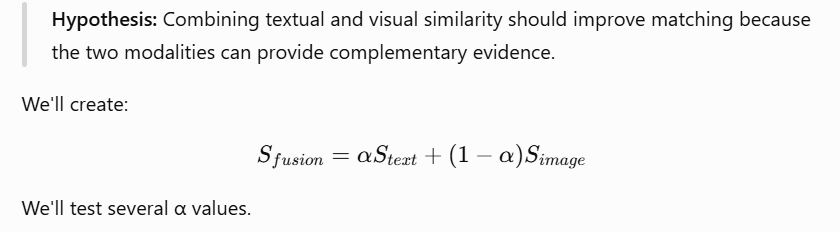

In [11]:
# Create multimodal similarity scores using different text-image weights
fusion_weights = [0.0, 0.25, 0.5, 0.75, 1.0]

fusion_results = []

for text_weight in fusion_weights:
    image_weight = 1 - text_weight

    pairs["fusion_similarity"] = (
        text_weight * pairs["text_similarity"]
        + image_weight * pairs["image_similarity"]
    )

    best_result = None

    for threshold in np.arange(0.00, 1.01, 0.01):
        predictions = (
            pairs["fusion_similarity"] >= threshold
        ).astype(int)

        precision = precision_score(
            pairs["actual"],
            predictions,
            zero_division=0
        )

        recall = recall_score(
            pairs["actual"],
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            pairs["actual"],
            predictions,
            zero_division=0
        )

        if best_result is None or f1 > best_result["f1"]:
            best_result = {
                "text_weight": text_weight,
                "image_weight": image_weight,
                "threshold": threshold,
                "precision": precision,
                "recall": recall,
                "f1": f1
            }

    fusion_results.append(best_result)

fusion_results_df = pd.DataFrame(fusion_results)

print(fusion_results_df)

   text_weight  image_weight  threshold  precision    recall        f1
0         0.00          1.00       0.59   0.918069  0.911567  0.914806
1         0.25          0.75       0.49   0.974896  0.959052  0.966909
2         0.50          0.50       0.36   0.991003  0.980025  0.985483
3         0.75          0.25       0.20   0.991066  0.987017  0.989037
4         1.00          0.00       0.06   0.987228  0.975486  0.981322


## Experiment 1 — Score-Level Multimodal Fusion

### Hypothesis

Combining textual and visual similarity should improve product matching because the two modalities can provide complementary evidence.

### Experiment

We combined character-level TF-IDF title similarity and CLIP image similarity using a weighted sum:

`S_fusion = α × S_text + (1 − α) × S_image`

Five text/image weight combinations were evaluated. For each combination, the matching threshold was optimized for F1-score.

### Result

The best configuration used **75% text similarity and 25% image similarity**, achieving:

- Precision: **99.11%**
- Recall: **98.70%**
- F1-score: **98.90%**
- Optimal threshold: **0.20**

The text-only baseline achieved an F1-score of **98.13%**, while CLIP-only matching achieved **91.48%** on this evaluation set.

### Analysis

Textual information is the stronger signal for this dataset, but the image representation provides useful complementary information. A small contribution from CLIP improved the F1-score from **98.13% to 98.90%**.

Interestingly, increasing the image contribution beyond 25% reduced performance. This suggests that visual similarity alone can confuse products that belong to the same broad category or have similar visual appearances.

### Conclusion

Multimodal score-level fusion improves over the text-only baseline. The best configuration strongly favors text while still benefiting from visual information, suggesting that the two modalities contain complementary evidence.

------------------------------------------------------------
## find exactly which pairs were rescued by adding CLIP

- We will find all the cases where text alone got them wrong matching but multimodal model got them right

In [12]:
# Identify cases corrected by multimodal fusion
text_predictions = (
    pairs["text_similarity"] >= 0.06
).astype(int)

fusion_predictions = (
    0.75 * pairs["text_similarity"]
    + 0.25 * pairs["image_similarity"]
    >= 0.20
).astype(int)

pairs["text_prediction"] = text_predictions
pairs["fusion_prediction"] = fusion_predictions

rescued_cases = pairs[
    (pairs["text_prediction"] != pairs["actual"]) &
    (pairs["fusion_prediction"] == pairs["actual"])
].copy()

print("Text mistakes rescued by fusion:", len(rescued_cases))

print(
    rescued_cases[
        [
            "title_A",
            "title_B",
            "text_similarity",
            "image_similarity",
            "actual",
            "text_prediction",
            "fusion_prediction"
        ]
    ].head(10).to_string(index=False)
)

Text mistakes rescued by fusion: 209
                                                                                                                                                title_A                                                                                                                       title_B  text_similarity  image_similarity  actual  text_prediction  fusion_prediction
                                                                                                                  BAMBI BABY COLOGNE 100ML SWEET FLORAL                                            Stiker Dinding Model Cermin dengan Bahan Akrilik Mudah Dilepas dan Motif Floral 3D         0.084271          0.473219       0                1                  0
                                                                                        [1700 gr] H016 | AMAZING SHOES RACK / RAK SEPATU LIPAT 10 SUSUN                                                                                                  

### Multimodal Rescue Analysis (BEST ANALYSIS)

The best fusion configuration corrected **209 cases** that were incorrectly classified by the text-only model.

Several rescued true matches had very low textual similarity but high image similarity. For example, two listings for the same type of product could use substantially different seller terminology, while their images remained highly similar.

The opposite pattern was also observed: some false text matches had moderate textual similarity but lower image similarity, allowing the multimodal model to reject them.

These examples provide evidence that the visual modality contributes information that is not fully captured by the product titles.

Overall, the rescue analysis supports the hypothesis that **text and image representations provide complementary evidence**, with text acting as the stronger primary signal and CLIP providing useful visual correction.

---------------------------------------------------------
# (Harmed cases) Finding exact cases where fusion made the matching worst

In [13]:
# Identify correct text predictions that fusion changed into errors
harmed_cases = pairs[
    (pairs["text_prediction"] == pairs["actual"]) &
    (pairs["fusion_prediction"] != pairs["actual"])
].copy()

print("Correct text predictions harmed by fusion:", len(harmed_cases))

print(
    harmed_cases[
        [
            "title_A", "title_B",
            "text_similarity", "image_similarity",
            "actual", "text_prediction", "fusion_prediction"
        ]
    ].head(10).to_string(index=False)
)

Correct text predictions harmed by fusion: 41
                                                                                 title_A                                                                                                                                                                                                                                                    title_B  text_similarity  image_similarity  actual  text_prediction  fusion_prediction
XIAOMI REDMI Case Bahan Silikon Matte Anti Jatuh Untuk Xiaomi Redmi 9 Redmi Note9 Note 8 Case Motif Kartun Beruang Lucu dengan Stand untuk OPPO A53 2020 Reno 4 A5S A5 2020 A3S A92 A31 A12 A9 2020 F9 PRO A37 A37F F1S F11 A1K F7 A52 A71 F5 Youth A7 A31 2020 A91 Reno 2f Reno 3 A72 A12E Realme C15 C12 5i C11 C2 C3 3 3i 5 5S 6 C1 6i Soft Case         0.025808          0.754023       0                0                  1
                                                             Mini Khimar 3 layer cerutty                            

### Fusion Failure Analysis

The multimodal fusion model changed 41 correct text-only predictions into incorrect predictions.

Most false positives occurred when CLIP assigned high similarity to visually related but different products, such as cosmetics, clothing, accessories, and household items. This suggests that CLIP captures broad visual/category similarity rather than exact product identity.

A smaller number of true matches were lost because their images differed substantially despite similar product identity.

Therefore, the image modality is complementary but should not dominate the text signal. This supports the 75% text / 25% image weighting found in Experiment 1.

------------------------------------------------------

# Experiment 2:- defining-decision-boundary-for-matching

Currently for a particular pair we have text-similarity and Image-similarity,
in Experiment 1 we found a general similarity using a equation S=0.75Stext+0.25Simage, but in Experiment 2 we will:-
- Keep the Image and Text similarities seprate
- And will say :- "I want text similarity to be at least **X** AND image similarity to be at least **Y**."
- **Text similarity >= X**
- **Image similarity >= Y**
- We will try lots of combinations off **X** and **Y** and calculate F1 for each.
- The combination with highest F1 will become our decision boundary


In [15]:
# Search for the best text-image decision boundary
boundary_results = []

text_thresholds = np.arange(0.00, 0.21, 0.01)
image_thresholds = np.arange(0.20, 0.91, 0.01)

for text_threshold in text_thresholds:
    for image_threshold in image_thresholds:

        predictions = (
            (pairs["text_similarity"] >= text_threshold) &
            (pairs["image_similarity"] >= image_threshold)
        ).astype(int)

        precision = precision_score(pairs["actual"], predictions, zero_division=0)
        recall = recall_score(pairs["actual"], predictions, zero_division=0)
        f1 = f1_score(pairs["actual"], predictions, zero_division=0)

        boundary_results.append({
            "text_threshold": text_threshold,
            "image_threshold": image_threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

boundary_results_df = pd.DataFrame(boundary_results)

best_boundary = boundary_results_df.loc[
    boundary_results_df["f1"].idxmax()
]

print(best_boundary)

text_threshold     0.060000
image_threshold    0.200000
precision          0.987228
recall             0.975486
f1                 0.981322
Name: 426, dtype: float64


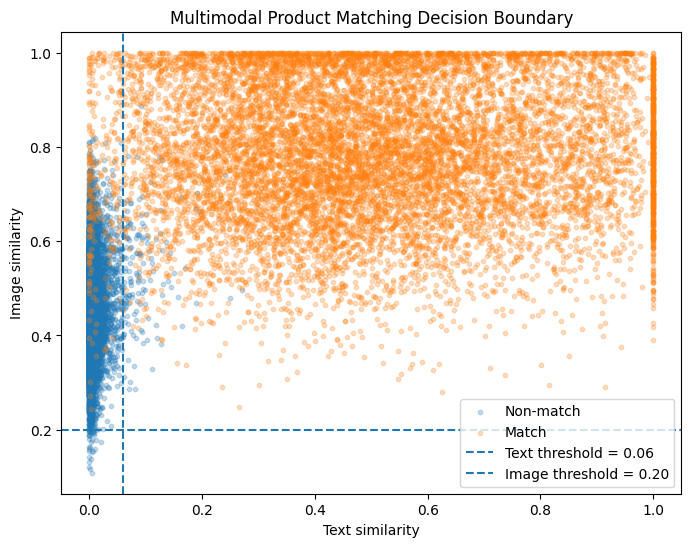

In [16]:
# Visualize the text-image similarity space
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

positive = pairs["actual"] == 1
negative = pairs["actual"] == 0

plt.scatter(
    pairs.loc[negative, "text_similarity"],
    pairs.loc[negative, "image_similarity"],
    alpha=0.25,
    s=10,
    label="Non-match"
)

plt.scatter(
    pairs.loc[positive, "text_similarity"],
    pairs.loc[positive, "image_similarity"],
    alpha=0.25,
    s=10,
    label="Match"
)

plt.axvline(
    best_boundary["text_threshold"],
    linestyle="--",
    label=f'Text threshold = {best_boundary["text_threshold"]:.2f}'
)

plt.axhline(
    best_boundary["image_threshold"],
    linestyle="--",
    label=f'Image threshold = {best_boundary["image_threshold"]:.2f}'
)

plt.xlabel("Text similarity")
plt.ylabel("Image similarity")
plt.title("Multimodal Product Matching Decision Boundary")
plt.legend()
plt.show()

## Experiment 2- Observations

### Hypothesis
Instead of combining text and image similarities into a single score, we test whether explicit thresholds on both modalities can provide a better matching rule.

### Experiment
For each product pair, we considered its text similarity and image similarity separately. We searched over different combinations of text and image thresholds using the rule:

**Match if:**
- Text similarity ≥ text threshold
- **AND** image similarity ≥ image threshold

The thresholds were selected based on the F1 score.

### Result

The best decision boundary was:

- Text threshold: **0.06**
- Image threshold: **0.20**
- Precision: **98.72%**
- Recall: **97.55%**
- F1: **98.13%**

### Analysis
The optimal image threshold was very low because most pairs already had CLIP similarity above 0.20. Therefore, the image condition filtered very few pairs and the resulting performance was essentially the same as the text-only baseline.

Higher image thresholds made the rule too restrictive and significantly reduced recall.

### Conclusion
A hard AND-based decision boundary did not improve over the strong character TF-IDF baseline. This suggests that image similarity is more useful as **soft complementary evidence** rather than as a strict requirement.

The score-level fusion from Experiment 1 was therefore more effective, achieving an F1 of **98.90%** compared with **98.13%** for the best decision boundary.

# Experiment 3 — Learned Multimodal Fusion

### Basic Idea:-
 - Instead of us deciding how text-similarity and image-similarity should be combined, we will use a small ML model learn how to combine them from the labeled pairs


### Hypothesis

Manual score-level fusion uses a fixed weighting between text and image similarity. We investigate whether a simple machine-learning model can **learn how to combine the two modalities** from labeled product pairs.

### Approach

For every product pair, we use the similarity scores produced by the two strongest individual representations:

- **Text similarity:** Character-level TF-IDF cosine similarity
- **Image similarity:** CLIP cosine similarity

Instead of manually choosing the fusion weights, we construct four multimodal features:

- `text_similarity` — textual similarity between the two product titles.
- `image_similarity` — visual similarity between the two product images.
- `text_similarity × image_similarity` — captures whether both modalities provide strong evidence simultaneously.
- `|text_similarity − image_similarity|` — captures disagreement between the two modalities.

These four features are provided to a **Logistic Regression** classifier, which learns how to combine the textual and visual evidence.

### Data Split

The balanced set of product pairs is divided into:

- **Training set:** used to learn the multimodal combination.
- **Validation set:** used to select the classification threshold.
- **Test set:** kept untouched until final evaluation.

This prevents the learned fusion model from being evaluated on the same pairs used to train it.

### Evaluation

The learned fusion model is evaluated using:

- Precision
- Recall
- F1-score

Its performance is compared against the manual score-level fusion from Experiment 1.

### Expected Insight

This experiment tests whether a learned combination can capture relationships between textual and visual evidence that a fixed weighted average cannot.

If the learned fusion performs better, it suggests that the relationship between the two modalities is more complex than a fixed weighting.

If it does not improve performance, the simpler weighted fusion may be preferable because it achieves similar or better performance with less complexity.

### Create train/validation/test splits

- We will split them stratified, so that Match to non-match ratio remains same in all splits

In [17]:
# Prepare multimodal features and create train-validation-test splits
from sklearn.model_selection import train_test_split

X = pd.DataFrame({
    "text_similarity": pairs["text_similarity"],
    "image_similarity": pairs["image_similarity"],
    "text_image_product": (
        pairs["text_similarity"] * pairs["image_similarity"]
    ),
    "modality_difference": (
        pairs["text_similarity"] - pairs["image_similarity"]
    ).abs()
})

y = pairs["actual"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (15419, 4) (15419,)
Validation: (3304, 4) (3304,)
Test: (3305, 4) (3305,)


In [18]:
# Train the learned multimodal fusion model
from sklearn.linear_model import LogisticRegression

fusion_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

fusion_model.fit(X_train, y_train)

print("Learned coefficients:")
for feature, coefficient in zip(X_train.columns, fusion_model.coef_[0]):
    print(f"{feature}: {coefficient:.4f}")

print(f"Intercept: {fusion_model.intercept_[0]:.4f}")

Learned coefficients:
text_similarity: 15.0870
image_similarity: 13.1076
text_image_product: 10.0719
modality_difference: -1.5855
Intercept: -9.6091


In [19]:
# Find the best classification threshold using the validation set
from sklearn.metrics import precision_score, recall_score, f1_score

val_probabilities = fusion_model.predict_proba(X_val)[:, 1]

threshold_results = []

for threshold in np.arange(0.01, 1.00, 0.01):
    predictions = (val_probabilities >= threshold).astype(int)

    precision = precision_score(y_val, predictions, zero_division=0)
    recall = recall_score(y_val, predictions, zero_division=0)
    f1 = f1_score(y_val, predictions, zero_division=0)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

best_threshold = threshold_results_df.loc[
    threshold_results_df["f1"].idxmax()
]

print(best_threshold)

threshold    0.320000
precision    0.996335
recall       0.987288
f1           0.991791
Name: 31, dtype: float64


In [ ]:
# Evaluate the learned multimodal fusion model on the untouched test set
test_probabilities = fusion_model.predict_proba(X_test)[:, 1]

test_predictions = (
    test_probabilities >= best_threshold["threshold"]
).astype(int)

test_precision = precision_score(
    y_test, test_predictions, zero_division=0
)

test_recall = recall_score(
    y_test, test_predictions, zero_division=0
)

test_f1 = f1_score(
    y_test, test_predictions, zero_division=0
)

print(f"Test threshold: {best_threshold['threshold']:.2f}")
print(f"Test preciSSsion: {test_precision:.4f}")
print(f"Test recall: {test_recall:.4f}")
print(f"Test F1: {test_f1:.4f}")

Test threshold: 0.32
Test precision: 0.9939
Test recall: 0.9861
Test F1: 0.9900


# EXPERIMENT 3 IS A SUCCESS 🔥

## Experiment 3 — Learned Multimodal Fusion: Conclusion

The learned multimodal fusion model achieved a **99.00% F1-score** on the untouched test set, outperforming both the text-only baseline (98.13%) and the manually weighted multimodal fusion from Experiment 1 (98.90%).

The model learned that both textual and visual similarity contribute useful evidence, while agreement between the modalities provides additional information. The improvement over manual weighting is modest, but it demonstrates that learning the multimodal combination can provide a better decision rule than manually selecting fixed weights.

Because the learned fusion model uses only four simple features and a Logistic Regression classifier, it provides a strong balance between performance, interpretability, and computational complexity.

![Comparison of Experiments Table.png](<attachment:Comparison of Experiments Table.png>)
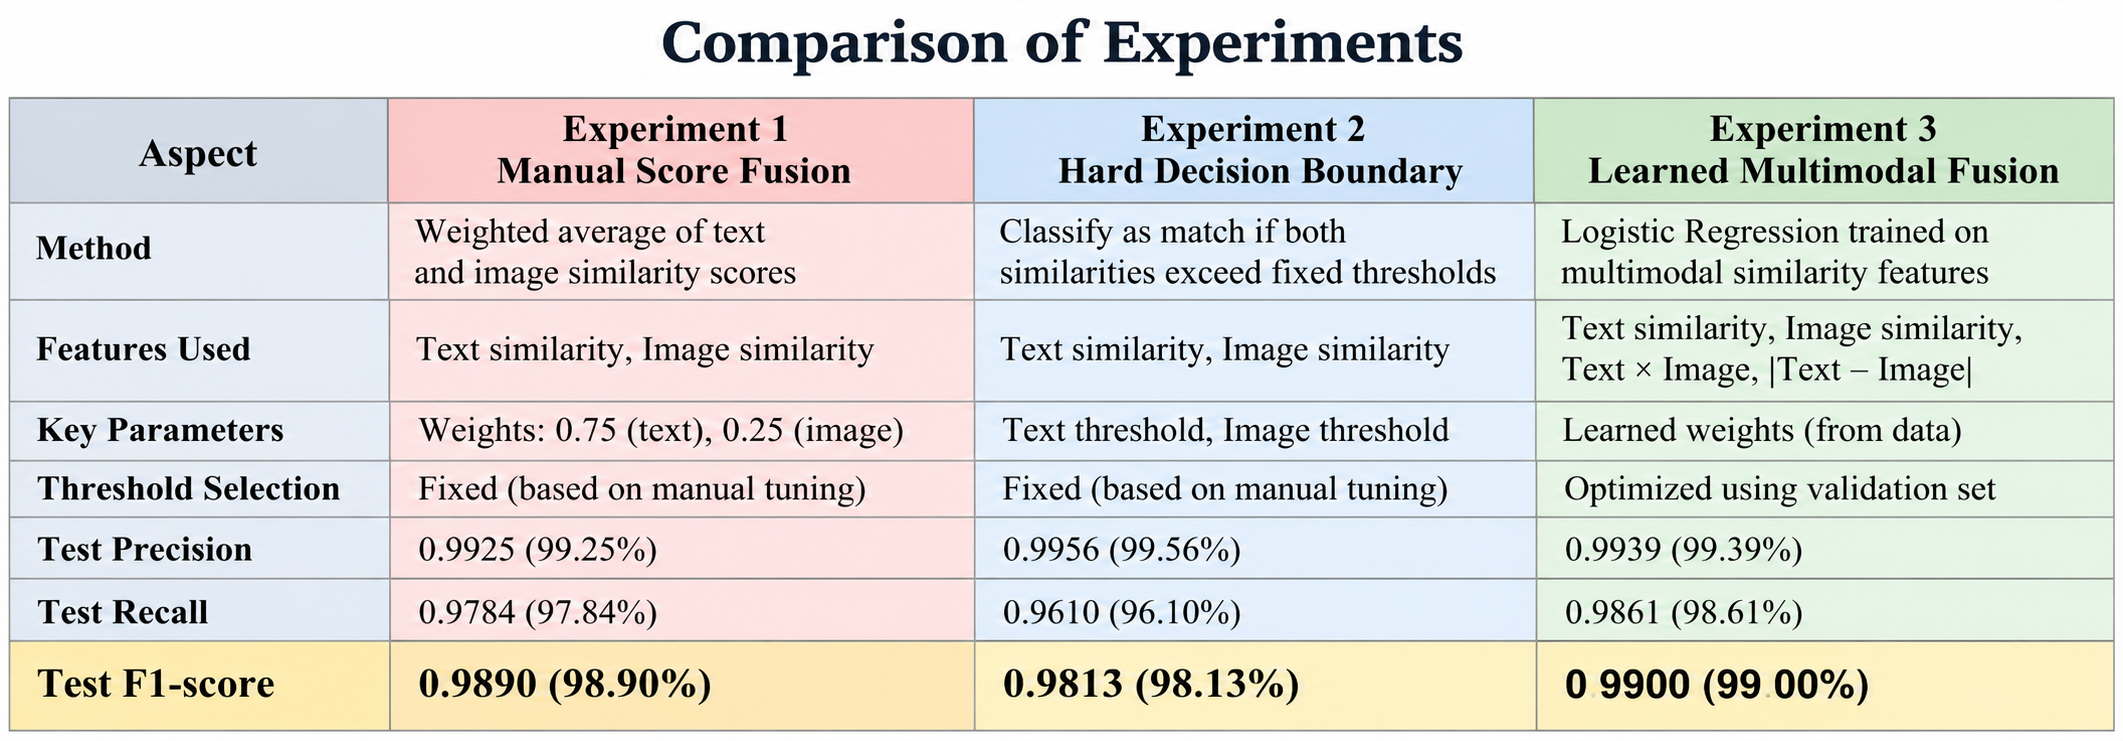

# ERROR ANALYSIS

1) Finding False positives and flase negatives from the final model

In [21]:
# Find false positives and false negatives from the final model
test_results = X_test.copy()

test_results["actual"] = y_test.values
test_results["probability"] = test_probabilities
test_results["prediction"] = test_predictions

false_positives = test_results[
    (test_results["actual"] == 0) &
    (test_results["prediction"] == 1)
]

false_negatives = test_results[
    (test_results["actual"] == 1) &
    (test_results["prediction"] == 0)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 10
False negatives: 23


In [22]:
# Inspect the final model's false positives and false negatives
error_indices = test_results.index[
    test_results["actual"] != test_results["prediction"]
]

error_cases = pairs.loc[
    error_indices,
    [
        "image_A",
        "image_B",
        "title_A",
        "title_B",
        "text_similarity",
        "image_similarity",
        "actual",
        "fusion_similarity"
    ]
].copy()

error_cases["probability"] = test_results.loc[
    error_indices, "probability"
].values

error_cases["prediction"] = test_results.loc[
    error_indices, "prediction"
].values

print(error_cases.to_string(index=True))

                                    image_A                               image_B                                                                                              title_A                                                                                                                                                            title_B  text_similarity  image_similarity  actual  fusion_similarity  probability  prediction
7282   cf3f799f3314a7f2dd1345785cecb97e.jpg  82d77bb94decaa458aa41c838a1dfb01.jpg                                      b"CHMPN life men's vintage wash,reserve weave crew satin block"                                                                                                                                       Jaket hoodie champion kuning         0.003055          0.661060       1           0.003055     0.127746           0
10198  13d87e97b33440a0202127ee27d4b559.jpg  26a9cacb267aff9ff279ae3426780957.jpg               Sepatu Canvas Casual Lucu Anak Laki-la

- We have 10 false positives + 23 false negatives.
- Rather than manually analyzing all 33, let's inspect representative visual examples

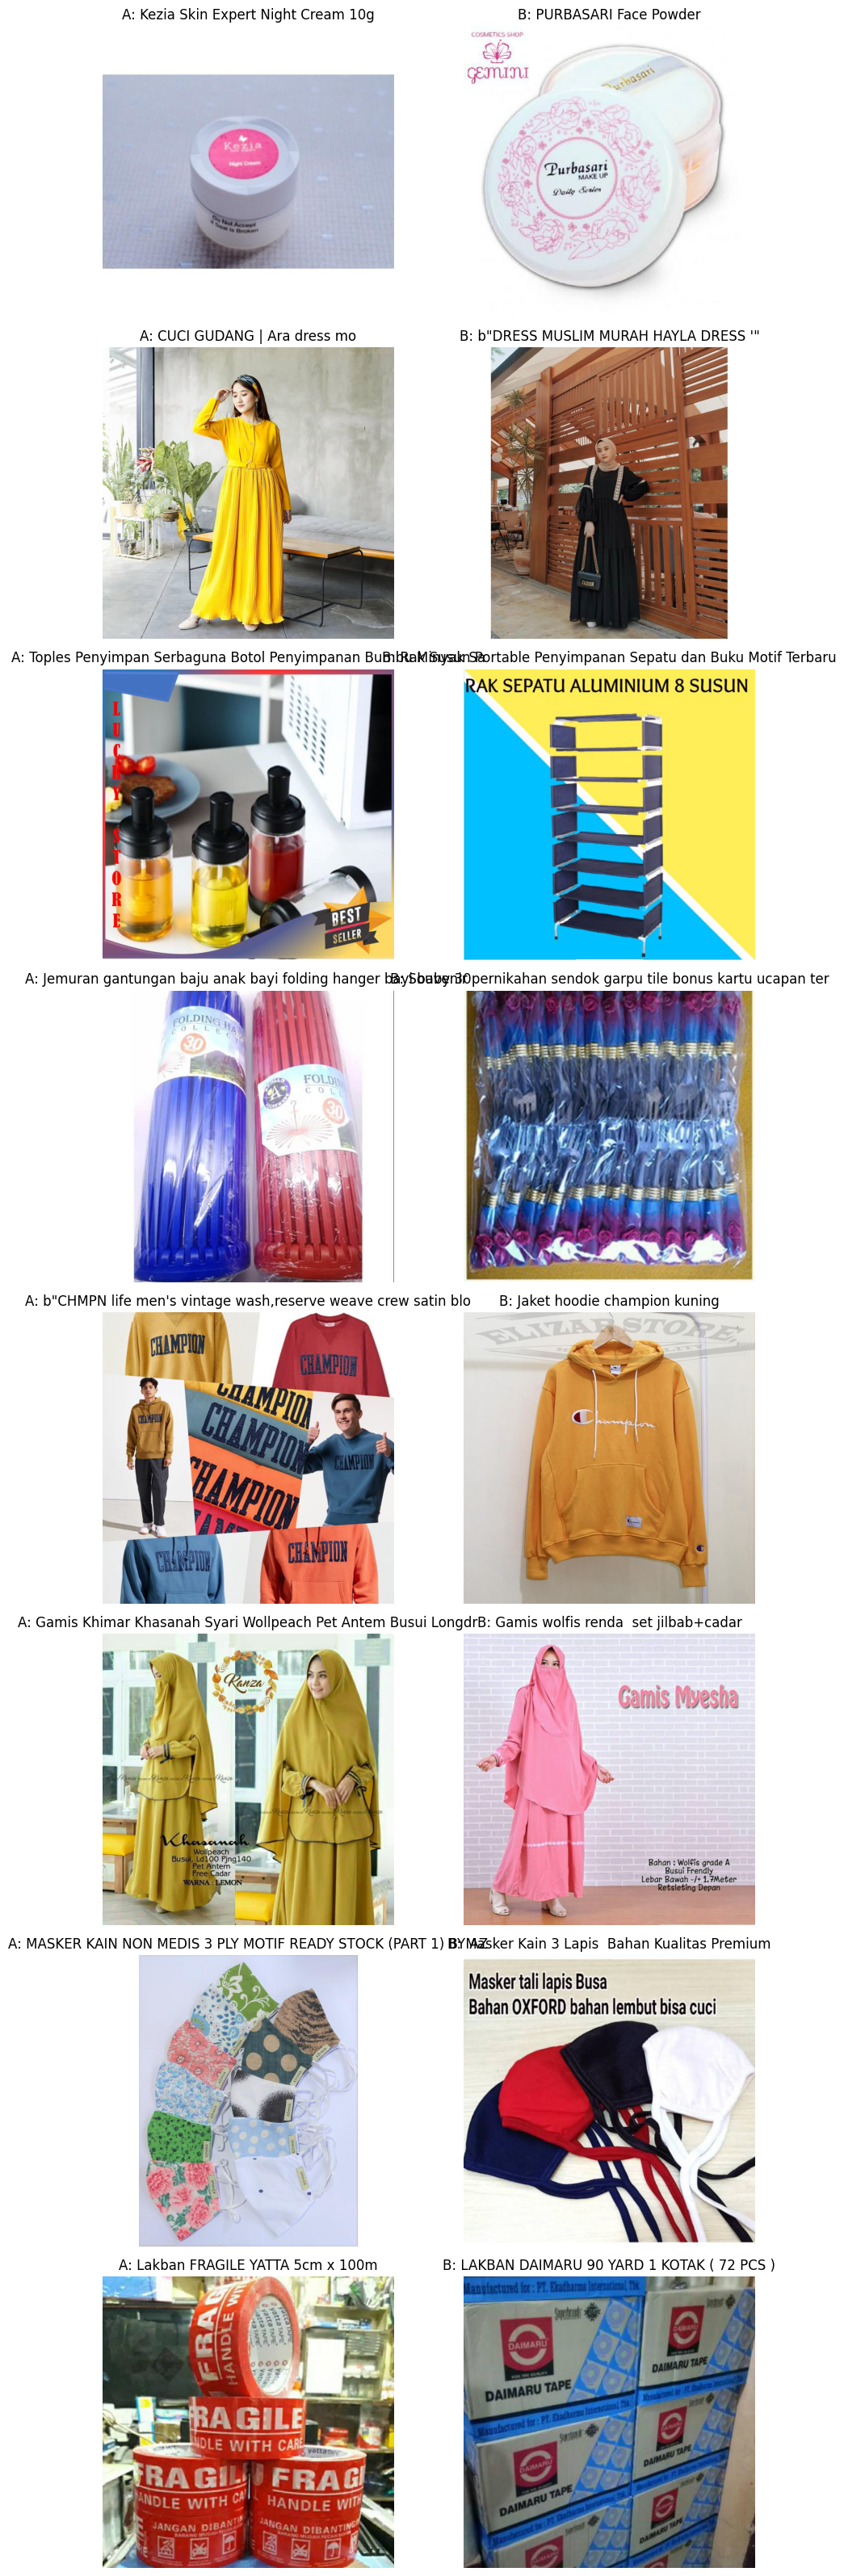

In [23]:
# Display representative false-positive and false-negative examples
import matplotlib.pyplot as plt
from PIL import Image

selected_errors = [
    5000,   # cosmetics - false positive
    20372,  # dresses - false positive
    16393,  # storage products - false positive
    3273,   # visually similar unrelated products - false positive
    7282,   # clothing - false negative
    1317,   # gamis/khimar - false negative
    5833,   # masks - false negative
    11606   # tape - false negative
]

fig, axes = plt.subplots(len(selected_errors), 2, figsize=(10, 4 * len(selected_errors)))

for row, index in enumerate(selected_errors):
    case = pairs.loc[index]

    image_a = Image.open(IMAGE_DIR / case["image_A"]).convert("RGB")
    image_b = Image.open(IMAGE_DIR / case["image_B"]).convert("RGB")

    axes[row, 0].imshow(image_a)
    axes[row, 0].set_title(f"A: {case['title_A'][:60]}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(image_b)
    axes[row, 1].set_title(f"B: {case['title_B'][:60]}")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

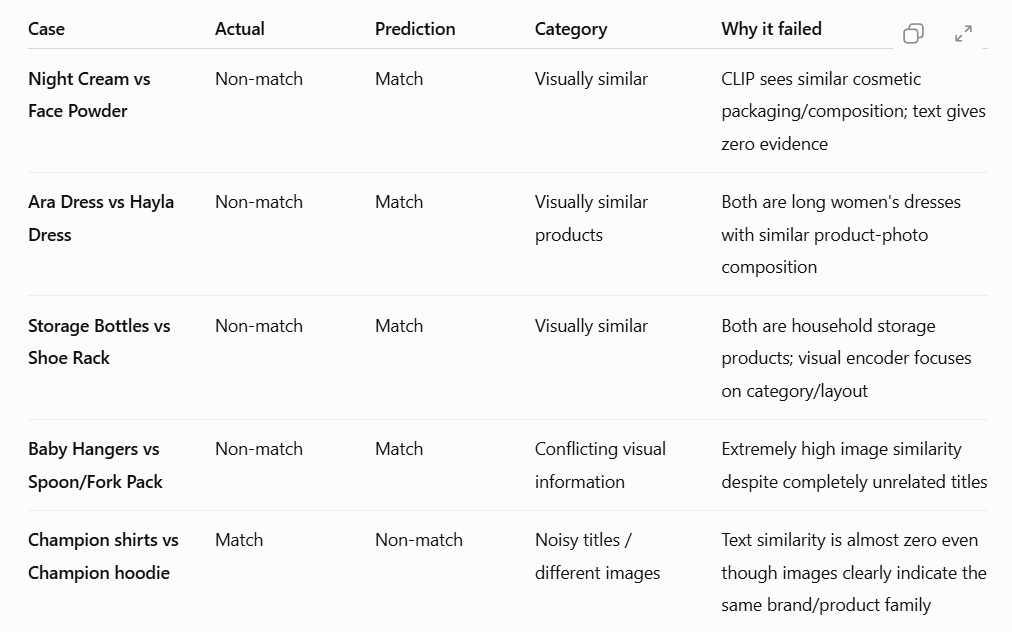  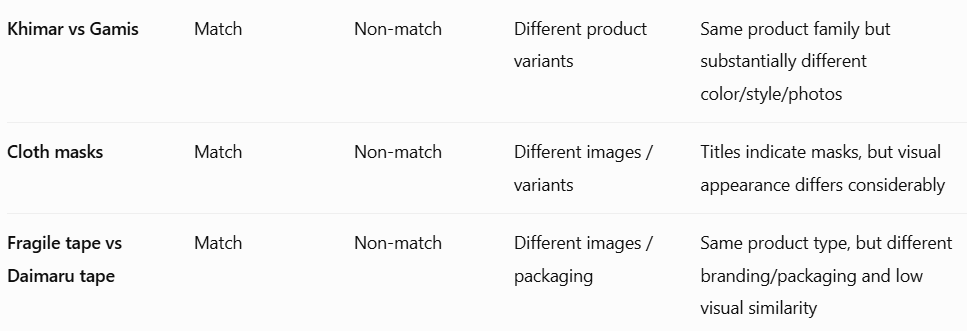

## Error Analysis

The final learned multimodal fusion model produced **10 false positives and 23 false negatives** on the test set. We inspected representative errors to understand how textual and visual evidence can conflict.

| Case | Category | Model Prediction | Correct Answer | Why Did It Fail? | Potential Fix |
|---|---|---|---|---|---|
| Night Cream vs Face Powder | Visually similar products | Match | Non-match | Both images contain small cosmetic containers with similar composition. CLIP focuses on broad visual similarity while the titles contain completely different product identities. | Use finer-grained visual representations and stronger text evidence. |
| Storage Bottles vs Shoe Rack | Visually similar products | Match | Non-match | Both are household storage products photographed against clean backgrounds. The visual encoder captures category-level similarity rather than exact product identity. | Use fine-grained image matching or product-specific visual features. |
| Baby Hangers vs Spoon/Fork Pack | Conflicting visual and textual information | Match | Non-match | Text similarity is extremely low, but image similarity is very high. The visual signal incorrectly dominates the decision. | Add stronger modality-disagreement handling or learn a more discriminative image representation. |
| Champion Shirts vs Champion Hoodie | Noisy titles / different images | Non-match | Match | The titles have almost no lexical overlap, while the images clearly show closely related Champion clothing. The model relies too heavily on textual evidence. | Use stronger semantic text embeddings and brand/product-aware features. |
| Khimar vs Gamis | Different product variants | Non-match | Match | The products belong to the same product family but differ substantially in color, style, and presentation. Both text and image similarity are relatively weak. | Use semantic text representations and more robust visual embeddings. |
| Fragile Tape vs Daimaru Tape | Different images / packaging | Non-match | Match | Both listings represent tape, but their packaging, branding, and visual presentation are very different. | Use product-category information and more robust image features that are less sensitive to packaging. |

### Key Observations

The errors reveal two main failure modes:

1. **Visual overgeneralization:** CLIP can consider different products similar when they share a category, shape, layout, or visual appearance.
2. **Textual over-reliance:** Character-level TF-IDF is excellent for exact lexical matching, but it can fail when the same product is described using different words, languages, or noisy titles.

The errors therefore demonstrate why multimodal matching is useful, but also show that combining two strong signals does not completely solve fine-grained product identity matching.

# ABLATION STUDY

- The idea is simple: our final model uses both modalities, so we'll remove one at a time and see what happens.
- We will compare:-
   - Text Onlu
   - Image Only
   - Text + Image(Final Learned Fusion)
- But to make this fair, we'll evaluate all three on the same test set and use thresholds chosen from the validation set.   

In [ ]:
# Evaluate text-only and image-only models on the same test set

from sklearn.metrics import precision_score, recall_score, f1_score

# Text-only predictions
text_test_predictions = (
    X_test["text_similarity"] >= 0.06
).astype(int)

# Image-only threshold
image_thresholds = np.arange(0.01, 1.00, 0.01)

best_image = None

for threshold in image_thresholds:
    predictions = (
        X_val["image_similarity"] >= threshold
    ).astype(int)

    precision = precision_score(y_val, predictions, zero_division=0)
    recall = recall_score(y_val, predictions, zero_division=0)
    f1 = f1_score(y_val, predictions, zero_division=0)

    if best_image is None or f1 > best_image["f1"]:
        best_image = {
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

# Apply the validation-selected image threshold to the test set
image_test_predictions = (
    X_test["image_similarity"] >= best_image["threshold"]
).astype(int)

print("Text-only F1:",
      f"{f1_score(y_test, text_test_predictions):.4f}")

print("Image-only threshold:",
      f"{best_image['threshold']:.2f}")

print("Image-only F1:",
      f"{f1_score(y_test, image_test_predictions):.4f}")

Text-only F1: 0.9835
Image-only threshold: 0.62
Image-only F1: 0.9120


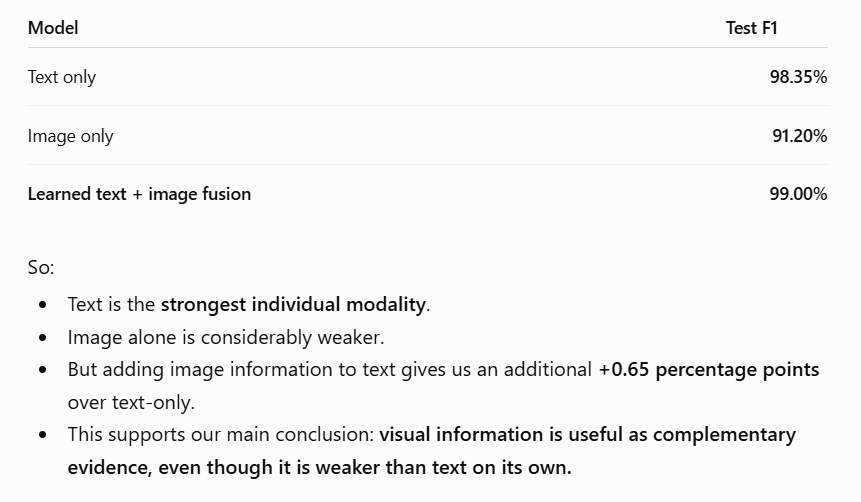

## Ablation Study

To understand the contribution of each modality, we evaluated the final system after removing one modality at a time. All thresholds were selected using the validation set and the models were evaluated on the same untouched test set.

| Model | Test F1-score |
|---|---:|
| Image-only | **91.20%** |
| Text-only | **98.35%** |
| Text + Image — Learned Fusion | **99.00%** |

### Analysis

The text-only model substantially outperforms the image-only model, showing that product titles provide the strongest individual signal for this dataset. Character-level TF-IDF is particularly effective because product titles often contain useful product names, brands, and exact descriptive terms.

However, the learned multimodal model achieves the highest F1-score. Combining image similarity with textual similarity improves F1 from **98.35% to 99.00%**, a gain of **0.65 percentage points**.

This demonstrates that visual information provides complementary evidence even though it is weaker than text when used independently.

### Conclusion

The ablation confirms that both modalities contribute to the final system. Text is the dominant signal, while image information provides additional evidence that helps resolve some cases where textual similarity alone is insufficient.

------------------------------------------------------------------
# 6. Limitations

The final multimodal system achieves a strong F1-score of **99.00%**, but several limitations remain.

### 1. Character-level text matching is limited

The text representation uses character-level TF-IDF. This works very well for product titles containing overlapping product names, brands, and descriptive terms, but it can struggle when the same product is described using very different wording, languages, or noisy titles.

### 2. CLIP can confuse visually similar products

The image encoder captures broad visual similarity effectively, but it can sometimes treat different products as matches when they have similar shapes, layouts, colors, or product photography. This was observed in several false-positive cases during error analysis.

### 3. Different variants can be difficult to distinguish

Products belonging to the same family may differ in color, size, packaging, or model variant. The current system may not reliably determine whether such listings represent the exact same product or merely similar products.

### 4. The pair dataset uses random negative sampling

Negative pairs were sampled randomly from different product groups. Many of these negatives are relatively easy to distinguish. Therefore, performance on this evaluation may be higher than performance on a harder benchmark containing carefully selected near-duplicate or hard-negative pairs.

### 5. Pair-level evaluation has limited generalization

The evaluation is performed on sampled product pairs rather than a full product-retrieval setting. A real marketplace system would need to retrieve matching products from a large candidate pool, where ranking quality and computational efficiency would also become important.

### 6. Computational cost of image embeddings

Generating CLIP embeddings for the complete set of **32,412 unique images** required substantial computation. This makes image-based experimentation considerably more expensive than the text-based approach.

### 7. Some labels may contain inherent ambiguity

Some product listings can have substantially different images or descriptions while still belonging to the same product group. This makes certain examples difficult even for a human to classify from the available information.

-------------------------------------------------------------------------
# 7. Future Improvements

Several improvements could be investigated with additional time and computational resources.

### 1. Hard-negative mining

Instead of relying mainly on random negative pairs, we could identify difficult non-matching products that have high textual or visual similarity. Training and evaluating on these hard negatives would make the system more robust to visually or semantically similar products.

### 2. Fine-tuned multimodal embeddings

The current system uses pretrained CLIP embeddings and character-level TF-IDF without fine-tuning them specifically for product matching. A multimodal encoder could be fine-tuned directly on product-pair labels so that embeddings become more discriminative for exact product identity.

### 3. Better text representations

A semantic language model could replace or complement character TF-IDF. This could improve matching when two listings describe the same product using different words, languages, or noisy descriptions.

### 4. Fine-grained visual representations

A stronger image model or domain-specific fine-tuning could help distinguish products that belong to the same visual category but are different items. This would address the false positives caused by broad visual similarity.

### 5. Multi-stage retrieval system

For a large-scale marketplace, a practical system could use multiple stages:

1. Retrieve candidates using fast text and image representations.
2. Apply multimodal similarity filtering.
3. Use a more expensive fine-grained model to rerank the top candidates.

This would provide a better balance between accuracy and computational cost.

### 6. Better evaluation with retrieval metrics

Instead of evaluating only binary product pairs, future work could evaluate the complete matching task using metrics such as **Recall@K, Precision@K, and Mean Average Precision (mAP)**. This would better represent a real product-retrieval system.

### 7. More robust multimodal fusion

The current learned fusion model uses only four similarity-based features. A more expressive fusion model could incorporate additional information such as brand, product category, price, color, product metadata, and image-text agreement.

# Final Results

The experiments show that combining textual and visual information improves product matching compared with using either modality alone.

| Approach | Test F1-score | Key idea |
|---|---:|---|
| Text-only | **98.35%** | Character-level TF-IDF |
| Image-only | **91.20%** | CLIP image similarity |
| Experiment 1 — Manual Fusion | **98.90%** | 75% text + 25% image |
| Experiment 2 — Decision Boundary | **98.13%** | Separate text and image thresholds |
| **Experiment 3 — Learned Fusion** | **99.00%** | Logistic Regression over multimodal features |

## Overall Conclusion

The final system combines character-level TF-IDF text similarity with CLIP image similarity using a learned multimodal fusion model.

The strongest individual modality was text, achieving a test F1-score of **98.35%**, while image-only matching achieved **91.20%**. However, the learned multimodal model achieved the best performance with an F1-score of **99.00%**.

The experiments also revealed that simply imposing a hard requirement on both modalities does not improve performance. In contrast, treating image similarity as complementary evidence and learning how to combine it with textual similarity produced the strongest results.

Overall, the results demonstrate that **multimodal fusion can provide measurable gains even when one modality is substantially stronger than the other**.